# Geopolitical Energy Shocks and European Equities: Sector Vulnerability, Relative Performance, and Investment Implications

## Executive Summary

- **Strongest overall sector:** The energy firms, Shell and TotalEnergies, show the strongest overall performance, combining the highest cumulative returns, strong benchmark-relative performance, and clear positive Brent sensitivity.
- **Weakest overall sector:** The chemicals sector appears weakest overall, with BASF performing poorly in both absolute and benchmark-relative terms, while Covestro is only moderately more resilient.
- **Most oil-linked names:** Shell and TotalEnergies are the clearest positive Brent-sensitive firms, while Ryanair and Lufthansa are clearly negative Brent-sensitive in the regression analysis.
- **Main analytical takeaway:** The project shows that geopolitical energy stress cannot be reduced to a simple oil story, because most firms remain strongly market-linked, and high oil volatility does not automatically favor energy equities.

## 1. Objective and Research Question

Main research question: How do geopolitical energy-shock periods affect the relative performance and vulnerability of selected European firms in airlines, transportation/logistics, chemicals, and energy?

- Sub-question 1: Which selected sectors and firms perform worst and best during geopolitical energy-stress periods?
- Sub-question 2: Are some firms within the same sector more resilient than others?
- Sub-question 3: How strongly do firm returns co-move with Brent during stress and non-stress periods?
- Sub-question 4: What investment conclusions can be drawn about sector vulnerability and resilience in Europe?

- Hypothesis 1: When oil prices rise sharply, energy firms should outperform the other selected sectors.
- Hypothesis 2: When oil prices rise sharply, airlines should underperform because of fuel-cost pressure and route disruption.
- Hypothesis 3: When oil prices rise sharply, transportation/logistics firms should underperform because of freight, fuel, and shipping-cost pressure.
- Hypothesis 4: When oil prices rise sharply, chemicals firms should underperform because of input-cost and margin pressure.
- Hypothesis 5: Within each sector, firms may react differently, suggesting that business model differences matter.

## 2. Data and Company Selection

Companies

- Airlines: Ryanair, Lufthansa
- Transportation/Logistics: DHL Group, Maersk
- Chemicals: BASF, Covestro
- Energy: Shell, TotalEnergies

Data:
- yfinance library

## 3. Methodology

### 3.1 Return Construction
Daily returns are computed from cleaned closing-price data for the selected firms, Brent crude, and STOXX Europe 600. The analysis uses simple percentage returns rather than log returns in order to keep interpretation more direct and readable. Missing price observations are handled using forward filling, followed by the removal of any remaining missing rows.

### 3.2 Benchmark-Relative performance
To evaluate whether firms outperform or underperform the broader European market, benchmark-relative daily returns are defined as company returns minus STOXX Europe 600 returns. Cumulative benchmark-relative performance is then measured as cumulative company return minus cumulative STOXX Europe 600 return. This allows the analysis to distinguish absolute stock performance from performance relative to the market.

### 3.3 Volatility Regime Definition
To study whether firm behavior changes across different oil-market environments, the project defines Brent volatility regimes using the 20-day rolling standard deviation of Brent daily returns. Days are classified into three regimes based on the 30th and 70th percentiles of this rolling volatility measure: Low_Vol, Normal, and High_Vol. Average raw returns and average benchmark-relative returns are then compared across these regimes.

### 3.4 Regression Framework

To separate broad market sensitivity from oil sensitivity, the project estimates a two-factor OLS regression for each firm. Daily company returns are regressed on STOXX Europe 600 returns and Brent returns. Robust HC3 standard errors are used in the final regression specification in order to make inference more reliable under heteroskedasticity. The main quantities of interest are the estimated market coefficient, the Brent coefficient, and the model R-squared.

## 4. Descriptive Performance Analysis

In [27]:
import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt
from datetime import datetime
import statsmodels.api as sm

In [28]:
ticker = { 
           'Ryanair': 'RYA.IR',
           'Lufthansa': 'LHA.DE',
           'DHL Group': 'DHL.DE',
           'Maersk': 'MAERSK-B.CO',
           'BASF': 'BAS.DE',
           'Covestro': '1COV.F',
           'Shell': 'SHEL.L',
           'TotalEnergies': 'TTE.PA',
           'STOXX Europe 600': '^STOXX',
           'Brent': 'BZ=F'
          }
start_date = datetime(year = 2022, month = 1, day = 1)
end_date = datetime(year = 2026, month = 3, day = 11)

In [29]:
data = yf.download(
    tickers = list(ticker.values()),
    start = start_date,
    end = end_date,
    interval = '1d',
    group_by = 'ticker',
    progress = False
)
data.head(5)

Ticker         RYA.IR                                              \
Price            Open       High        Low      Close     Volume   
Date                                                                
2022-01-03        NaN        NaN        NaN        NaN        NaN   
2022-01-04  15.123091  16.050451  15.118336  15.788888  4607009.0   
2022-01-05  15.693774  16.259700  15.679507  15.945825  2539278.0   
2022-01-06  15.708040  16.169343  15.660484  15.893512  1307576.0   
2022-01-07  15.860222  16.083740  15.727064  16.083740  1708220.0   

Ticker       MAERSK-B.CO                                                     \
Price               Open          High           Low         Close   Volume   
Date                                                                          
2022-01-03  13060.542612  13370.453793  12922.189407  13337.249023  23192.0   
2022-01-04  13431.329153  13536.477589  13292.975948  13436.863281  21216.0   
2022-01-05  13503.271951  13730.171193  13292.975093  13553.079102  21353.0   
2022-01-06  13392.589307  13470.067096  13055.007510  13126.951172  25441.0   
2022-01-07  13160.156513  13425.794659  13121.417616  13292.975586  21234.0   

Ticker      ...      ^STOXX                                                   \
Price       ...        Open        High         Low       Close       Volume   
Date        ...                                                                
2022-01-03  ...  488.279999  491.429993  488.279999  489.989990   80135100.0   
2022-01-04  ...  492.100006  495.459991  492.100006  494.019989  205338100.0   
2022-01-05  ...  493.989990  495.269989  493.309998  494.350006  171862500.0   
2022-01-06  ...  491.790009  491.790009  486.279999  488.160004  190008500.0   
2022-01-07  ...  487.970001  488.209991  484.149994  486.250000  181192700.0   

Ticker        LHA.DE                                            
Price           Open      High       Low     Close      Volume  
Date                                                            
2022-01-03  5.757186  6.133705  5.729836  6.133705  19693885.0  
2022-01-04  6.199345  6.480139  6.161966  6.427262  22050463.0  
2022-01-05  6.393531  6.570394  6.351594  6.525723  12036258.0  
2022-01-06  6.363446  6.563101  6.316950  6.450966  10712855.0  
2022-01-07  6.450966  6.474669  6.359798  6.441849   6941694.0  

[5 rows x 50 columns]

In [30]:
close_prices = data.xs('Close', axis = 1, level = 'Price')
close_prices.head()

Ticker,RYA.IR,MAERSK-B.CO,1COV.F,SHEL.L,BZ=F,BAS.DE,TTE.PA,DHL.DE,^STOXX,LHA.DE
Date,,,,,,,,,,
2022-01-03,NaN,13337.249023,51.009502,NaN,78.980003,48.044025,35.599403,50.864090,489.989990,6.133705
2022-01-04,15.788888,13436.863281,51.899200,1697.934448,80.000000,50.139904,35.900093,51.716965,494.019989,6.427262
2022-01-05,15.945825,13553.079102,52.992794,1719.298340,80.800003,50.539120,36.331341,52.034523,494.350006,6.525723
2022-01-06,15.893512,13126.951172,52.566479,1715.305176,81.989998,50.523766,36.347160,51.000183,488.160004,6.450966
2022-01-07,16.083740,13292.975586,53.196682,1733.674438,81.750000,50.754082,36.762577,50.573750,486.250000,6.441849


In [31]:
reverse_ticker = {v : k for k, v in ticker.items()}
close_prices = close_prices.rename(columns = reverse_ticker)
close_prices.head()

Ticker,Ryanair,Maersk,Covestro,Shell,Brent,BASF,TotalEnergies,DHL Group,STOXX Europe 600,Lufthansa
Date,,,,,,,,,,
2022-01-03,NaN,13337.249023,51.009502,NaN,78.980003,48.044025,35.599403,50.864090,489.989990,6.133705
2022-01-04,15.788888,13436.863281,51.899200,1697.934448,80.000000,50.139904,35.900093,51.716965,494.019989,6.427262
2022-01-05,15.945825,13553.079102,52.992794,1719.298340,80.800003,50.539120,36.331341,52.034523,494.350006,6.525723
2022-01-06,15.893512,13126.951172,52.566479,1715.305176,81.989998,50.523766,36.347160,51.000183,488.160004,6.450966
2022-01-07,16.083740,13292.975586,53.196682,1733.674438,81.750000,50.754082,36.762577,50.573750,486.250000,6.441849


In [32]:
close_prices.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 1081 entries, 2022-01-03 to 2026-03-10
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Ryanair           1065 non-null   float64
 1   Maersk            1049 non-null   float64
 2   Covestro          1067 non-null   float64
 3   Shell             1056 non-null   float64
 4   Brent             1052 non-null   float64
 5   BASF              1067 non-null   float64
 6   TotalEnergies     1071 non-null   float64
 7   DHL Group         1061 non-null   float64
 8   STOXX Europe 600  1051 non-null   float64
 9   Lufthansa         1067 non-null   float64
dtypes: float64(10)
memory usage: 92.9 KB


In [33]:
close_prices.isna().sum().sort_values(ascending = False)

Ticker
Maersk              32
STOXX Europe 600    30
Brent               29
Shell               25
DHL Group           20
Ryanair             16
Covestro            14
BASF                14
Lufthansa           14
TotalEnergies       10
dtype: int64

In [34]:
close_prices_clean = close_prices.ffill()
close_prices_clean.isna().sum().sort_values(ascending = False)

Ticker
Ryanair             1
Shell               1
Maersk              0
Covestro            0
Brent               0
BASF                0
TotalEnergies       0
DHL Group           0
STOXX Europe 600    0
Lufthansa           0
dtype: int64

In [35]:
prices = close_prices_clean.dropna()
prices.isna().sum()

Ticker
Ryanair             0
Maersk              0
Covestro            0
Shell               0
Brent               0
BASF                0
TotalEnergies       0
DHL Group           0
STOXX Europe 600    0
Lufthansa           0
dtype: int64

In [36]:
returns = prices.pct_change().dropna()
returns.head()

Ticker,Ryanair,Maersk,Covestro,Shell,Brent,BASF,TotalEnergies,DHL Group,STOXX Europe 600,Lufthansa
Date,,,,,,,,,,
2022-01-05,0.009940,0.008649,0.021071,0.012582,0.010000,0.007962,0.012012,0.006140,0.000668,0.015319
2022-01-06,-0.003281,-0.031441,-0.008045,-0.002323,0.014728,-0.000304,0.000435,-0.019878,-0.012521,-0.011456
2022-01-07,0.011969,0.012648,0.011989,0.010709,-0.002927,0.004559,0.011429,-0.008361,-0.003913,-0.001413
2022-01-10,-0.003253,-0.029975,-0.016376,-0.003455,-0.010764,-0.000303,0.006027,-0.040007,-0.014828,0.028588
2022-01-11,0.000890,0.003434,-0.002480,0.016064,0.035242,0.009079,0.018400,0.008970,0.008433,-0.002614


In [76]:
company_returns = returns.drop(columns = ['Brent', 'STOXX Europe 600'])
relative_returns = company_returns.sub(returns['STOXX Europe 600'], axis = 0)
relative_returns.head()

Ticker,Ryanair,Maersk,Covestro,Shell,BASF,TotalEnergies,DHL Group,Lufthansa
Date,,,,,,,,
2022-01-05,0.009272,0.007981,0.020403,0.011914,0.007294,0.011344,0.005472,0.014651
2022-01-06,0.009241,-0.018920,0.004477,0.010199,0.012218,0.012957,-0.007356,0.001066
2022-01-07,0.015882,0.016560,0.015901,0.014622,0.008471,0.015342,-0.004449,0.002499
2022-01-10,0.011575,-0.015147,-0.001549,0.011373,0.014525,0.020854,-0.025179,0.043415
2022-01-11,-0.007544,-0.005000,-0.010913,0.007630,0.000645,0.009966,0.000537,-0.011048


In [38]:
extreme_returns = pd.DataFrame({
    'Minimum daily return': returns.min(),
    'Maximum daily return': returns.max()
})
extreme_returns

,Minimum daily return,Maximum daily return
Ticker,,
Ryanair,-0.171481,0.090423
Maersk,-0.169332,0.112236
Covestro,-0.087154,0.133101
Shell,-0.085037,0.080506
Brent,-0.131583,0.087941
BASF,-0.078589,0.107077
TotalEnergies,-0.064181,0.081736
DHL Group,-0.072484,0.141862
STOXX Europe 600,-0.051212,0.046842


In [39]:
cumulative_returns = (1+returns).cumprod() -1
cumulative_returns.tail()

Ticker,Ryanair,Maersk,Covestro,Shell,Brent,BASF,TotalEnergies,DHL Group,STOXX Europe 600,Lufthansa
Date,,,,,,,,,,
2026-03-04,0.710063,0.266665,0.159170,0.804251,0.017500,-0.079575,0.862391,-0.069551,0.240254,0.305066
2026-03-05,0.642294,0.260711,0.163794,0.830459,0.067625,-0.073991,0.859884,-0.112670,0.224303,0.263368
2026-03-06,0.658762,0.272246,0.162253,0.845183,0.158625,-0.097126,0.894146,-0.107256,0.211874,0.263368
2026-03-09,0.616327,0.233175,0.161868,0.888765,0.237000,-0.106700,0.918937,-0.120018,0.204243,0.182774
2026-03-10,0.668262,0.216058,0.159941,0.873158,0.097500,-0.085559,0.914758,-0.095655,0.226914,0.276126


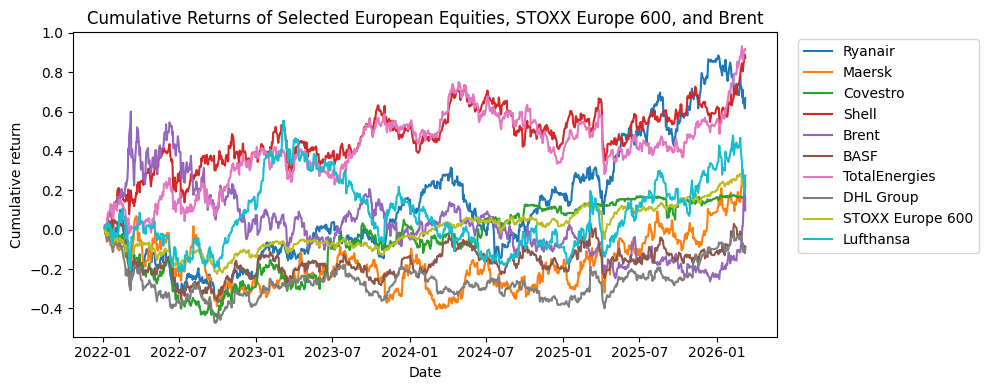

In [40]:
plt.figure(figsize = (10,4))
plt.plot(cumulative_returns)
plt.title('Cumulative Returns of Selected European Equities, STOXX Europe 600, and Brent')
plt.xlabel('Date')
plt.ylabel('Cumulative return')
plt.legend(cumulative_returns.columns, bbox_to_anchor= (1.02, 1), loc = 'upper left')
plt.tight_layout()
plt.show()

Top 3 visual observations:
- Shell, Ryanair, and TotalEnergies appear to be among the stronger performers by the end of the sample,
- Brent, Lufthansa, and Ryanair appear visually more volatile than the STOXX Europe 600, with Lufthansa showing frequent changes in direction over time,
- The transportation/logistics firms, especially DHL and Maersk, appear weaker than the other selected sectors for much of the sample, while Brent and the energy firms seem to share a broadly similar directional pattern in several periods.

In [41]:
final_cum_returns = pd.DataFrame({
    'Final Cumulative Return': cumulative_returns.iloc[-1]
})
final_cum_returns = final_cum_returns.sort_values(by = 'Final Cumulative Return', ascending = False)
final_cum_returns

,Final Cumulative Return
Ticker,
TotalEnergies,0.914758
Shell,0.873158
Ryanair,0.668262
Lufthansa,0.276126
STOXX Europe 600,0.226914
Maersk,0.216058
Covestro,0.159941
Brent,0.097500
BASF,-0.085559


Interpretation of the table:
- The strongest final performers are TotalEnergies, Shell, and Ryanair;
- DHL Group and BASF are the weakest final performers, both ending the sample with negative cumulative returns;
- Energy equities outperform Brent itself over the full sample, suggesting that firm-level equity performance is not just a mirror of the commodity path.

In [42]:
daily_return_vol = pd.DataFrame({
    'Daily Return Volatility': returns.std()
})
daily_return_vol =daily_return_vol.sort_values(by = 'Daily Return Volatility', ascending = False)
daily_return_vol

,Daily Return Volatility
Ticker,
Maersk,0.025869
Brent,0.021886
Lufthansa,0.021119
Ryanair,0.019905
Covestro,0.017961
BASF,0.017956
DHL Group,0.017225
TotalEnergies,0.015187
Shell,0.014987


Interpretations:
- Ryanair combines strong final performance with relatively high volatility, whereas Lufthansa is also highly volatile but delivers a much weaker final cumulative return than the top-performing names;
- Brent is one of the most volatile series in the sample, but the European energy companies, especially TotalEnergies and Shell, achieve much stronger final performance with lower day-to-day volatility than Brent itself;
- Maersk is the most volatile series in the sample and, despite that risk, does not deliver especially strong final performance, which shows that visually reading the cumulative-return chart alone can be misleading.

In [43]:
average_daily_return = pd.DataFrame({
    'Average Daily Return': returns.mean()
})
average_daily_return = average_daily_return.sort_values(by = 'Average Daily Return', ascending = False)
average_daily_return

,Average Daily Return
Ticker,
TotalEnergies,0.000718
Shell,0.000695
Ryanair,0.000674
Maersk,0.000518
Lufthansa,0.000448
Brent,0.000327
Covestro,0.000297
STOXX Europe 600,0.000229
BASF,0.000078


Interpretations:
- TotalEnergies, Shell, and Ryanair have the highest average daily returns in the sample, which is consistent with their strong cumulative performance over the full period,
- Maersk combines relatively high average daily return with the highest volatility, suggesting that its return profile is much riskier than that of the strongest energy names.

In [44]:
summary_table = pd.concat([final_cum_returns, average_daily_return, daily_return_vol], axis = 1)
summary_table

,Final Cumulative Return,Average Daily Return,Daily Return Volatility
Ticker,,,
TotalEnergies,0.914758,0.000718,0.015187
Shell,0.873158,0.000695,0.014987
Ryanair,0.668262,0.000674,0.019905
Lufthansa,0.276126,0.000448,0.021119
STOXX Europe 600,0.226914,0.000229,0.008858
Maersk,0.216058,0.000518,0.025869
Covestro,0.159941,0.000297,0.017961
Brent,0.097500,0.000327,0.021886
BASF,-0.085559,0.000078,0.017956


The summary statistics show clear cross-sector differences across the selected European names. TotalEnergies and Shell deliver the strongest overall performance, combining the highest final cumulative returns and average daily returns with only moderate volatility relative to the most unstable series. Ryanair also performs strongly, but with higher volatility, while Lufthansa shows a weaker return profile despite similar sector exposure. Among the transportation and logistics firms, Maersk remains positive but highly volatile, whereas DHL Group appears comparatively weak. BASF is also among the weakest names in the sample, ending with a negative cumulative return. Overall, the results suggest that the energy firms were the strongest performers in this period, while transportation/logistics and some industrial-chemical names were more fragile.

## 5. Benchmark-Relative Analysis

In [45]:
company_cols = ['BASF', 'Shell', 'Ryanair', 'Lufthansa', 'Maersk', 'Covestro', 
                'TotalEnergies', 'DHL Group']
cumulative_relative_performance = cumulative_returns[company_cols].sub(
    cumulative_returns['STOXX Europe 600'],
    axis = 0
)
final_cum_rel_returns = pd.DataFrame({
    'Final Cumulative Relative Return': cumulative_relative_performance.iloc[-1]
}).sort_values(by = 'Final Cumulative Relative Return', ascending = False)
final_cum_rel_returns

,Final Cumulative Relative Return
Ticker,
TotalEnergies,0.687844
Shell,0.646244
Ryanair,0.441348
Lufthansa,0.049213
Maersk,-0.010856
Covestro,-0.066973
BASF,-0.312473
DHL Group,-0.322568


In [77]:
average_daily_rel_returns = pd.DataFrame({
    'Average Daily Relative Return': relative_returns.mean()
})
average_daily_rel_returns = average_daily_rel_returns.sort_values(by = 'Average Daily Relative Return', ascending = False)
average_daily_rel_returns

,Average Daily Relative Return
Ticker,
TotalEnergies,0.000489
Shell,0.000466
Ryanair,0.000445
Maersk,0.000289
Lufthansa,0.000219
Covestro,0.000068
BASF,-0.000151
DHL Group,-0.000175


In [78]:
daily_rel_return_vol = pd.DataFrame({
    'Daily Relative Return Volatility': relative_returns.std()
})
daily_rel_return_vol =daily_rel_return_vol.sort_values(by = 'Daily Relative Return Volatility', ascending = False)
daily_rel_return_vol

,Daily Relative Return Volatility
Ticker,
Maersk,0.024255
Lufthansa,0.018632
Ryanair,0.017517
Covestro,0.017015
BASF,0.014654
Shell,0.014585
TotalEnergies,0.013881
DHL Group,0.013288


In [48]:
relative_summary_table = pd.concat([final_cum_rel_returns, average_daily_rel_returns, daily_rel_return_vol,], axis = 1)
relative_summary_table

,Final Cumulative Relative Return,Average Daily Relative Return,Daily Relative Return Volatility
Ticker,,,
TotalEnergies,0.687844,0.000489,0.013881
Shell,0.646244,0.000466,0.014585
Ryanair,0.441348,0.000445,0.017517
Lufthansa,0.049213,0.000219,0.018632
Maersk,-0.010856,0.000289,0.024255
Covestro,-0.066973,0.000068,0.017015
BASF,-0.312473,-0.000151,0.014654
DHL Group,-0.322568,-0.000175,0.013288


Interpretion:
- TotalEnergies, Shell, and Ryanair are the strongest benchmark outperformers in the sample, suggesting that both the energy sector and Ryanair as an individual airline name were relatively resilient compared with the broader European equity market.
- BASF and DHL Group are the weakest names in benchmark-relative terms, while Maersk is much closer to market-like performance despite its high volatility.

## 6. Brent and Market Exposure

In [49]:
corr_with_brent = pd.DataFrame({
    'Correlation with Brent': company_returns.corrwith(returns['Brent'])
})
corr_with_brent = corr_with_brent.sort_values(by = 'Correlation with Brent', ascending = False)
corr_with_brent

,Correlation with Brent
Ticker,
Shell,0.478409
TotalEnergies,0.431059
Maersk,0.073464
Covestro,0.025792
BASF,0.018749
DHL Group,-0.050750
Lufthansa,-0.137617
Ryanair,-0.145378


Interpretations:
- Shell and TotalEnergies have the strongest positive correlations with Brent daily returns, which supports the view that the energy firms are the most directly linked to oil-price movements in the sample.
- Ryanair and Lufthansa show negative correlations with Brent, consistent with the idea that airlines are hurt when oil prices rise, although the relationship is only moderate rather than extremely strong.

In [50]:
corr_with_stoxx600 = pd.DataFrame({
    'Correlation with STOXX Europe 600': company_returns.corrwith(returns['STOXX Europe 600'])
})
corr_with_stoxx600 = corr_with_stoxx600.sort_values(by = 'Correlation with STOXX Europe 600', ascending = False)
corr_with_stoxx600

,Correlation with STOXX Europe 600
Ticker,
DHL Group,0.650760
BASF,0.585143
Ryanair,0.475906
Lufthansa,0.473933
TotalEnergies,0.432712
Covestro,0.350589
Maersk,0.347782
Shell,0.340313


In [51]:
correlation_summary = pd.concat([corr_with_stoxx600, corr_with_brent], axis = 1)
correlation_summary['STOXX minus Brent Correlation'] = correlation_summary['Correlation with STOXX Europe 600'].sub(correlation_summary['Correlation with Brent'])
correlation_summary = correlation_summary.sort_values(by = 'STOXX minus Brent Correlation', ascending = False)
correlation_summary

,Correlation with STOXX Europe 600,Correlation with Brent,STOXX minus Brent Correlation
Ticker,,,
DHL Group,0.650760,-0.050750,0.701510
Ryanair,0.475906,-0.145378,0.621284
Lufthansa,0.473933,-0.137617,0.611550
BASF,0.585143,0.018749,0.566394
Covestro,0.350589,0.025792,0.324797
Maersk,0.347782,0.073464,0.274318
TotalEnergies,0.432712,0.431059,0.001653
Shell,0.340313,0.478409,-0.138095


The STOXX-minus-Brent comparison suggests that most of the selected firms are more market-linked than Brent-linked. This is especially clear for DHL Group, Ryanair, Lufthansa, and BASF, whose returns appear much more closely aligned with the broader European market than with oil-price movements. The airline names remain negatively correlated with Brent, which is consistent with fuel-cost pressure, but their larger positive correlation with STOXX Europe 600 suggests that general market conditions are the more important day-to-day driver over the full sample. In the energy sector, the picture is different: TotalEnergies appears almost equally linked to both STOXX Europe 600 and Brent, while Shell is the only company in the sample that appears more Brent-linked than market-linked. Within transportation/logistics, DHL Group is far more market-linked than Maersk, suggesting that the two firms are affected by different combinations of market-wide and oil-related forces.

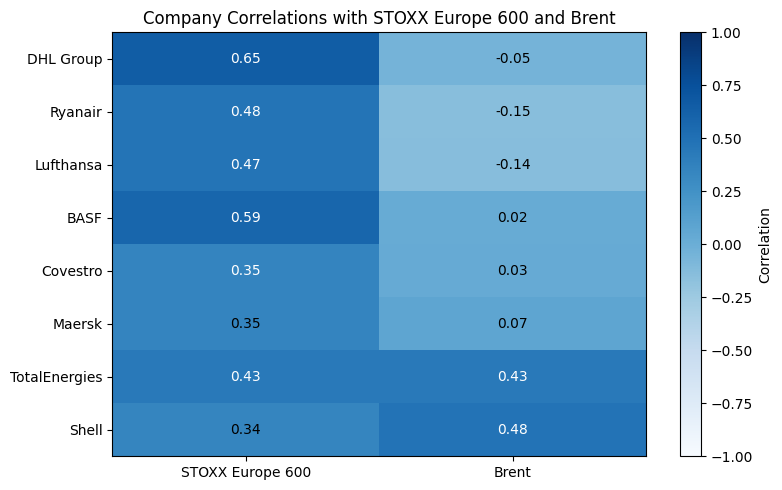

In [91]:
plt.figure(figsize=(8, 5))

corr_matrix = correlation_summary[['Correlation with STOXX Europe 600', 'Correlation with Brent']]

plt.imshow(corr_matrix, aspect='auto', cmap= 'Blues', vmin = -1, vmax = 1)

plt.colorbar(label='Correlation')

plt.xticks(
    ticks=[0, 1],
    labels=['STOXX Europe 600', 'Brent']
)

plt.yticks(
    ticks=range(len(corr_matrix.index)),
    labels=corr_matrix.index
)

for i in range(corr_matrix.shape[0]):
    for j in range(corr_matrix.shape[1]):
        plt.text(
            j, i,
            f"{corr_matrix.iloc[i, j]:.2f}",
            ha='center',
            va='center',
            color='white' if abs(corr_matrix.iloc[i, j]) > 0.35 else 'black'
        )

plt.title('Company Correlations with STOXX Europe 600 and Brent')
plt.tight_layout()
plt.show()

Interpretations:
- Most selected firms are more strongly linked to the broad European market than to Brent, so oil is not the sole driver of performance;
- DHL Group and BASF, which are among the weaker performers in the sample, show moderate-to-strong correlation with STOXX Europe 600 but very weak correlation with Brent. This suggests that their day-to-day stock movements were more closely linked to broader market conditions than to oil-price movements specifically;
- Ryanair and Lufthansa also show fairly strong correlation with STOXX Europe 600, but their Brent correlations are negative rather than near zero. This is consistent with the idea that airlines are negatively exposed to higher oil prices, although Brent does not appear to be the only important driver of airline returns;
- Shell and TotalEnergies show the strongest positive correlations with Brent while also remaining correlated with the broader market. This supports the view that the energy firms are the most directly oil-linked names in the sample;
- Maersk is less tightly linked to Brent than one might expect, suggesting that shipping/logistics performance is driven by a broader set of forces than oil prices alone.

## 7. Regime Analysis

In [53]:
brent = pd.DataFrame({
    'Brent return': returns['Brent'],
    '20-day rolling volatility of Brent return' : returns['Brent'].rolling(20).std()
})
brent

,Brent return,20-day rolling volatility of Brent return
Date,,
2022-01-05,0.010000,NaN
2022-01-06,0.014728,NaN
2022-01-07,-0.002927,NaN
2022-01-10,-0.010764,NaN
2022-01-11,0.035242,NaN
...,...,...
2026-03-04,0.000000,0.024020
2026-03-05,0.049263,0.024143
2026-03-06,0.085236,0.029113


Volatility regimes:
- low_volatility threshold = 30th percentile
- high_volatility = 70th percetile

Day classifications:
- Low Volatility
- Normal
- High Volatility

In [54]:
x = brent['20-day rolling volatility of Brent return']
low_vol = x.quantile(0.30)
high_vol = x.quantile(0.70)
conditions = [
    x <= low_vol,
    x >= high_vol
]
choices = ['Low_Vol', 'High_Vol']
brent['Volatility regime'] = np.select(conditions, choices, default = 'Normal')
brent.tail(10)

,Brent return,20-day rolling volatility of Brent return,Volatility regime
Date,,,
2026-02-25,0.001130,0.023386,High_Vol
2026-02-26,-0.001411,0.022164,Normal
2026-02-27,0.024452,0.022812,Normal
2026-03-02,0.072572,0.022926,High_Vol
2026-03-03,0.047080,0.024487,High_Vol
2026-03-04,0.000000,0.024020,High_Vol
2026-03-05,0.049263,0.024143,High_Vol
2026-03-06,0.085236,0.029113,High_Vol
2026-03-09,0.067645,0.031315,High_Vol


In [55]:
brent['Volatility regime'].value_counts()

Volatility regime
Normal      443
Low_Vol     318
High_Vol    318
Name: count, dtype: int64

In [56]:
returns_with_regime = returns.copy()
returns_with_regime['Volatility regime'] = brent['Volatility regime']
returns_with_regime.head()

Ticker,Ryanair,Maersk,Covestro,Shell,Brent,BASF,TotalEnergies,DHL Group,STOXX Europe 600,Lufthansa,Volatility regime
Date,,,,,,,,,,,
2022-01-05,0.009940,0.008649,0.021071,0.012582,0.010000,0.007962,0.012012,0.006140,0.000668,0.015319,Normal
2022-01-06,-0.003281,-0.031441,-0.008045,-0.002323,0.014728,-0.000304,0.000435,-0.019878,-0.012521,-0.011456,Normal
2022-01-07,0.011969,0.012648,0.011989,0.010709,-0.002927,0.004559,0.011429,-0.008361,-0.003913,-0.001413,Normal
2022-01-10,-0.003253,-0.029975,-0.016376,-0.003455,-0.010764,-0.000303,0.006027,-0.040007,-0.014828,0.028588,Normal
2022-01-11,0.000890,0.003434,-0.002480,0.016064,0.035242,0.009079,0.018400,0.008970,0.008433,-0.002614,Normal


In [57]:
avg_return_by_vol_reg = returns_with_regime.drop(['Brent', 'STOXX Europe 600'], axis =1).groupby('Volatility regime').mean()
avg_return_by_vol_reg

Ticker,Ryanair,Maersk,Covestro,Shell,BASF,TotalEnergies,DHL Group,Lufthansa
Volatility regime,,,,,,,,
High_Vol,0.001816,0.001169,0.000989,0.001069,0.001279,0.000820,0.000107,0.002084
Low_Vol,0.000093,0.001380,0.000370,0.001163,-0.000213,0.001089,0.000363,-0.000173
Normal,0.000272,-0.000568,-0.000252,0.000090,-0.000575,0.000378,-0.000205,-0.000281


In [68]:
high = avg_return_by_vol_reg.loc['High_Vol']
low = avg_return_by_vol_reg.loc['Low_Vol']
high_minus_low = pd.DataFrame({
    'High_Vol minus Low_Vol': high - low
})
high_minus_low = high_minus_low.sort_values(by = 'High_Vol minus Low_Vol', ascending = False)
high_minus_low

,High_Vol minus Low_Vol
Ticker,
Lufthansa,0.002257
Ryanair,0.001722
BASF,0.001491
Covestro,0.000619
Shell,-0.000094
Maersk,-0.000211
DHL Group,-0.000257
TotalEnergies,-0.000269


Interpretations:
- Lufthansa and Ryanair have the largest positive High_Vol minus Low_Vol differences, meaning their average daily returns were higher in high Brent-volatility periods than in low-volatility periods in this sample'
- The energy firms do not show strong positive High_Vol minus Low_Vol differences, suggesting that high oil volatility is not automatically favorable for energy equities, even though those firms are strongly linked to Brent in the broader correlation analysis.

In [95]:
rel_returns_with_regime = relative_returns.copy()
rel_returns_with_regime['Volatility regime'] = brent['Volatility regime']
rel_returns_with_regime.head()

Ticker,Ryanair,Maersk,Covestro,Shell,BASF,TotalEnergies,DHL Group,Lufthansa,Volatility regime
Date,,,,,,,,,
2022-01-05,0.009272,0.007981,0.020403,0.011914,0.007294,0.011344,0.005472,0.014651,Normal
2022-01-06,0.009241,-0.018920,0.004477,0.010199,0.012218,0.012957,-0.007356,0.001066,Normal
2022-01-07,0.015882,0.016560,0.015901,0.014622,0.008471,0.015342,-0.004449,0.002499,Normal
2022-01-10,0.011575,-0.015147,-0.001549,0.011373,0.014525,0.020854,-0.025179,0.043415,Normal
2022-01-11,-0.007544,-0.005000,-0.010913,0.007630,0.000645,0.009966,0.000537,-0.011048,Normal


In [60]:
avg_rel_return_by_vol_reg = rel_returns_with_regime.groupby('Volatility regime').mean()
avg_rel_return_by_vol_reg

Ticker,Ryanair,Maersk,Covestro,Shell,BASF,TotalEnergies,DHL Group,Lufthansa
Volatility regime,,,,,,,,
High_Vol,0.001401,0.000755,0.000575,0.000654,0.000864,0.000406,-0.000308,0.001669
Low_Vol,-0.000229,0.001057,0.000048,0.000840,-0.000535,0.000766,0.000041,-0.000496
Normal,0.000243,-0.000597,-0.000280,0.000062,-0.000604,0.000350,-0.000233,-0.000309


In [69]:
rel_high = avg_rel_return_by_vol_reg.loc['High_Vol']
rel_low = avg_rel_return_by_vol_reg.loc['Low_Vol']
rel_high_minus_low = pd.DataFrame({
    'High_Vol minus Low_Vol': rel_high - rel_low
}).sort_values(by = 'High_Vol minus Low_Vol', ascending = False)
rel_high_minus_low

,High_Vol minus Low_Vol
Ticker,
Lufthansa,0.002165
Ryanair,0.001630
BASF,0.001399
Covestro,0.000527
Shell,-0.000186
Maersk,-0.000303
DHL Group,-0.000349
TotalEnergies,-0.000361


The regime-based relative return table suggests that the effect of high Brent volatility differs across firms and sectors. Ryanair and Lufthansa both show stronger benchmark-relative performance in the high-volatility regime than in the low-volatility regime, and the same is true for BASF and Covestro. In contrast, the energy firms show weaker relative performance in the high-volatility regime than in the low-volatility regime. The transportation/logistics pair is mixed: Maersk remains positively relative in the high-volatility regime, while DHL Group becomes negative. Overall, the results suggest that high oil volatility does not affect all sectors in the same way, and even firms within the same sector can respond differently.

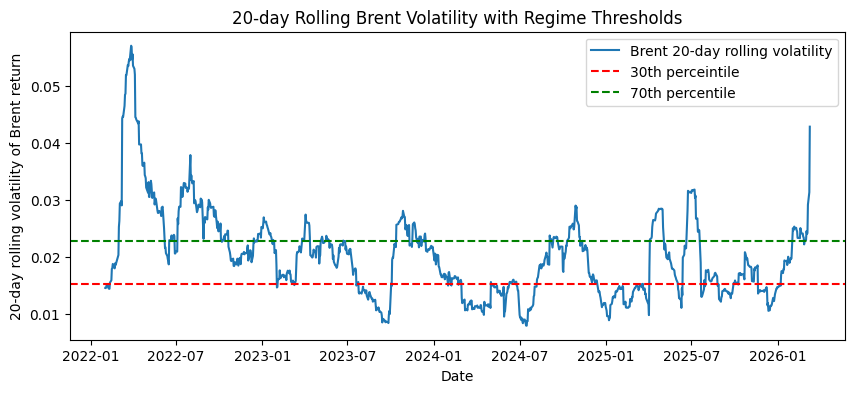

In [62]:
plt.figure(figsize =(10,4))
plt.plot(brent['20-day rolling volatility of Brent return'], label = 'Brent 20-day rolling volatility')
plt.axhline(low_vol, linestyle = '--', color = 'r', label = '30th perceintile')
plt.axhline(high_vol, linestyle = '--', color = 'g', label = '70th percentile')
plt.xlabel('Date')
plt.ylabel('20-day rolling volatility of Brent return')
plt.title('20-day Rolling Brent Volatility with Regime Thresholds')
plt.legend()
plt.show()

## 8. Regression Analysis

In [71]:
y = returns['Shell']
x = returns[['STOXX Europe 600', 'Brent']]
X = sm.add_constant(x)
model = sm.OLS(y, X)
results = model.fit()
results.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  Shell   R-squared:                       0.333
Model:                            OLS   Adj. R-squared:                  0.332
Method:                 Least Squares   F-statistic:                     269.2
Date:                Sun, 15 Mar 2026   Prob (F-statistic):           1.61e-95
Time:                        13:35:24   Log-Likelihood:                 3220.7
No. Observations:                1079   AIC:                            -6435.
Df Residuals:                    1076   BIC:                            -6421.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
====================================================================================
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const                0.0005      0.000      1.246      0.213      -0.000       0.001
STOXX Europe 600     0.5476      0.042     12.996      0.000       0.465       0.630
Brent                0.3197      0.017     18.746      0.000       0.286       0.353
==============================================================================
Omnibus:                       88.019   Durbin-Watson:                   2.194
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              466.867
Skew:                          -0.085   Prob(JB):                    4.18e-102
Kurtosis:                       6.218   Cond. No.                         113.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

The OLS regression for Shell shows that both STOXX Europe 600 returns and Brent returns are significant positive drivers of Shell’s daily returns. Holding Brent constant, a 1% rise in STOXX Europe 600 is associated with an estimated 0.55% increase in Shell’s return, while holding the market constant, a 1% rise in Brent is associated with an estimated 0.32% increase. The model explains about 33% of the variation in Shell’s daily returns, which is meaningful for daily stock-return data. Overall, the regression suggests that Shell behaves both as a market-linked equity and as an oil-linked stock, with market sensitivity somewhat stronger than Brent sensitivity.

In [98]:
shell_regression_summary = pd.DataFrame({
    'Metric': ['R-squared', 'STOXX coefficient', 'Brent coefficient', 'STOXX p-value', 'Brent p-value'],
    'Value': [
        results.rsquared,
        results.params['STOXX Europe 600'],
        results.params['Brent'],
        results.pvalues['STOXX Europe 600'],
        results.pvalues['Brent']
    ]
})
shell_regression_summary

,Metric,Value
0,R-squared,4.289680e-01
1,STOXX coefficient,1.270577e+00
2,Brent coefficient,-5.829407e-02
3,STOXX p-value,4.665712e-108
4,Brent p-value,1.387798e-02


In [97]:
companies = ['BASF', 'Shell', 'Ryanair', 'Lufthansa', 'Maersk', 'Covestro', 'TotalEnergies', 'DHL Group']
robust_regression_results = []

X = returns[['STOXX Europe 600', 'Brent']]
X = sm.add_constant(X)

for company in companies:
    y = returns[company]
    model = sm.OLS(y, X)
    results = model.fit(cov_type = 'HC3')
    
    robust_regression_results.append({
    'Company': company,
    'R-squared': results.rsquared,
    'STOXX coefficient': results.params['STOXX Europe 600'],
    'Brent coefficient':  results.params['Brent'],
    'STOXX p-value': results.pvalues['STOXX Europe 600'],
    'Brent p-value': results.pvalues['Brent']
    })

robust_regression_summary = pd.DataFrame(robust_regression_results)
robust_regression_summary = robust_regression_summary.sort_values(by = 'Brent coefficient', ascending = False)

def classify_brent_sensitivity(row):
    if row['Brent p-value'] < 0.05 and row['Brent coefficient'] > 0:
        return 'Positive Brent sensitivity'
    elif row['Brent p-value'] < 0.05 and row['Brent coefficient'] < 0:
        return 'Negative Brent sensitivity'
    else:
        return 'Weak/insignificant Brent sensitivity'

robust_regression_summary['Oil sensitivity type'] = robust_regression_summary.apply(classify_brent_sensitivity, axis = 1)
robust_regression_table = robust_regression_summary.drop(['STOXX p-value', 'Brent p-value'], axis = 1)
robust_regression_table

,Company,R-squared,STOXX coefficient,Brent coefficient,Oil sensitivity type
1,Shell,0.333492,0.547599,0.319699,Positive Brent sensitivity
6,TotalEnergies,0.360197,0.716438,0.288779,Positive Brent sensitivity
4,Maersk,0.124685,1.009304,0.072256,Weak/insignificant Brent sensitivity
5,Covestro,0.123089,0.709897,0.010912,Weak/insignificant Brent sensitivity
0,BASF,0.342397,1.186285,-0.001752,Weak/insignificant Brent sensitivity
7,DHL Group,0.428968,1.270577,-0.058294,Negative Brent sensitivity
2,Ryanair,0.252882,1.082475,-0.147857,Negative Brent sensitivity
3,Lufthansa,0.248523,1.143096,-0.149305,Negative Brent sensitivity


Interpretations:
- Most firms remain strongly linked to STOXX Europe 600, meaning market-wide conditions are important across the sample;
- Both Shell and TotalEnergies are the clearest positive oil-sensitivity names in the sample, even after controlling for the broader European market;
- Both Lufthansa and Ryanair exhibit significant negative oil sensitivity, consistent with the idea that higher Brent returns are associated with lower airline returns after controlling for the market;
- DHL Group and BASF appear primarily market-sensitive rather than oil-sensitive in this regression framework;
- Maersk shows only weak or insignificant direct Brent sensitivity once robust standard errors are used, suggesting that its returns are better understood as market-linked and business-model-specific rather than clearly oil-driven.

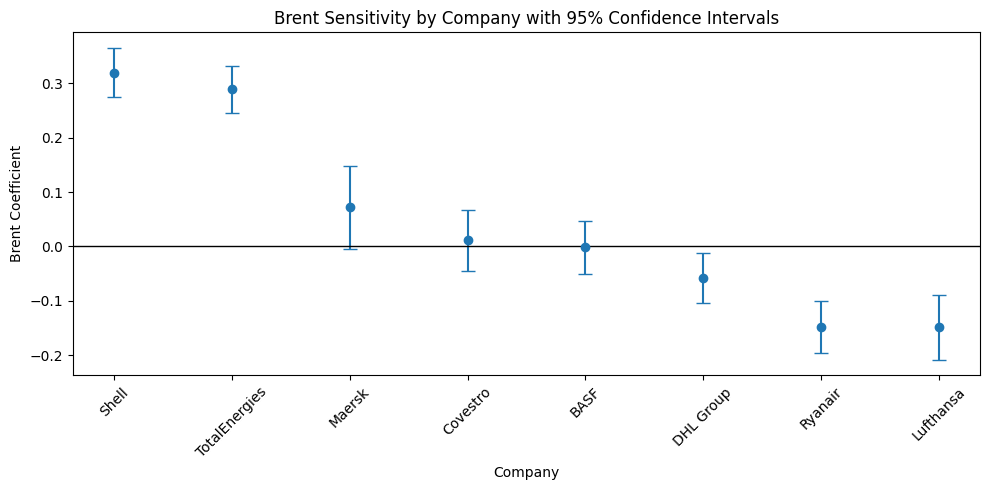

In [84]:
coef_plot_data = []

X = returns[['STOXX Europe 600', 'Brent']]
X = sm.add_constant(X)

for company in companies:
    y = returns[company]
    model = sm.OLS(y, X)
    results = model.fit(cov_type='HC3')
    
    coef_plot_data.append({
        'Company': company,
        'Brent coefficient': results.params['Brent'],
        'CI lower': results.conf_int().loc['Brent', 0],
        'CI upper': results.conf_int().loc['Brent', 1]
    })

coef_plot_df = pd.DataFrame(coef_plot_data)
coef_plot_df = coef_plot_df.sort_values(by='Brent coefficient', ascending=False).reset_index(drop=True)

plt.figure(figsize=(10, 5))

plt.errorbar(
    coef_plot_df['Company'],
    coef_plot_df['Brent coefficient'],
    yerr=[
        coef_plot_df['Brent coefficient'] - coef_plot_df['CI lower'],
        coef_plot_df['CI upper'] - coef_plot_df['Brent coefficient']
    ],
    fmt='o',
    capsize=5
)

plt.axhline(0, color='black', linewidth=1)
plt.title('Brent Sensitivity by Company with 95% Confidence Intervals')
plt.xlabel('Company')
plt.ylabel('Brent Coefficient')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

The coefficient plot confirms that Shell and TotalEnergies are the clearest positive Brent-sensitive firms in the sample, while Ryanair, Lufthansa, and DHL Group show clearly negative Brent sensitivity. In contrast, Maersk, Covestro, and BASF have Brent coefficients that are much closer to zero and whose confidence intervals overlap zero, suggesting weak or statistically uncertain direct Brent sensitivity. This visual therefore strengthens the cross-sector interpretation by separating strong Brent-linked firms from firms whose apparent oil exposure is not robust.

## 9. Sector-Pair Comparisons

### Ryanair vs Lufthansa

Within the airline sector, Ryanair appears to be the stronger name over the sample. It delivers a much higher final cumulative return than Lufthansa and also achieves substantially stronger benchmark-relative performance versus STOXX Europe 600. At the same time, Lufthansa shows slightly higher daily return volatility, which means Ryanair combines better performance with somewhat lower risk. The regression results show that both airlines are significantly negatively exposed to Brent and positively exposed to the broader market, with Lufthansa being only slightly more sensitive to both factors. Overall, the evidence suggests that the two firms share a similar exposure structure, but Ryanair converts that exposure into a much stronger return profile.

### Shell vs TotalEnergies

Within the energy sector, both Shell and TotalEnergies are clear standout names in the sample. Each delivers strong absolute and benchmark-relative performance, with TotalEnergies holding a modest edge over Shell in both final cumulative return and cumulative outperformance versus STOXX Europe 600. In risk terms, the two firms are fairly similar, although TotalEnergies is slightly more volatile. The regression results show that both companies are significantly positively exposed to Brent and to the broader market, but with different balances: Shell is somewhat more Brent-sensitive, while TotalEnergies is more market-sensitive. Overall, the two firms share a strong energy-linked profile, but TotalEnergies appears to have converted that exposure into slightly stronger overall performance.

### Maersk vs DHL Group

Within transportation and logistics, Maersk and DHL Group show very different risk-return profiles. Maersk ends the sample with a positive cumulative return, while DHL Group finishes moderately negative, so Maersk is the stronger absolute performer. However, Maersk is also the most volatile name in the entire sample, whereas DHL Group is much more stable, meaning Maersk’s stronger performance comes with substantially higher risk. In benchmark-relative terms, both firms underperform STOXX Europe 600, but Maersk remains much closer to benchmark-like performance, while DHL underperforms more clearly. The regression results reinforce the contrast: Maersk has modest positive Brent sensitivity and strong market sensitivity, whereas DHL is more strongly market-linked but negatively exposed to Brent. Overall, Maersk looks like the riskier but stronger logistics name, while DHL appears more stable but also more structurally weak in this sample.

### Covestro vs BASF

Within the chemicals sector, Covestro appears to be the stronger name in the sample. It ends the period with a positive cumulative return, while BASF finishes negative, and Covestro also performs less poorly relative to STOXX Europe 600. In risk terms, the two firms are quite similar, with comparable daily return volatility. The regression results add an important layer: neither company shows meaningful direct Brent sensitivity, which suggests that oil is not the dominant explanatory factor for their daily returns. Instead, both firms are more closely linked to the broader market, especially BASF. Overall, the evidence suggests that the chemicals pair is more market-driven than oil-driven, with Covestro showing the more resilient return profile.

## 10. Final Cross-Sector Summary Table

In [96]:
sector_map = {
    'Shell': 'Energy',
    'TotalEnergies': 'Energy',
    'Ryanair': 'Airlines',
    'Lufthansa': 'Airlines',
    'Maersk': 'Transportation/Logistics',
    'DHL Group': 'Transportation/Logistics',
    'BASF': 'Chemicals',
    'Covestro': 'Chemicals'
}

final_summary_table = pd.DataFrame({
    'Sector': pd.Series(sector_map),
    'Final Cumulative Return': final_cum_returns['Final Cumulative Return'],
    'Final Cumulative Relative Return': final_cum_rel_returns['Final Cumulative Relative Return'],
    'Daily Return Volatility': daily_return_vol['Daily Return Volatility'],
    'Brent coefficient': robust_regression_table.set_index('Company')['Brent coefficient'],
    'Oil sensitivity type': robust_regression_table.set_index('Company')['Oil sensitivity type']
})

final_summary_table = final_summary_table.sort_values(by='Final Cumulative Return', ascending=False)
final_summary_table

,Sector,Final Cumulative Return,Final Cumulative Relative Return,Daily Return Volatility,Brent coefficient,Oil sensitivity type
TotalEnergies,Energy,0.914758,0.687844,0.015187,0.288779,Positive Brent sensitivity
Shell,Energy,0.873158,0.646244,0.014987,0.319699,Positive Brent sensitivity
Ryanair,Airlines,0.668262,0.441348,0.019905,-0.147857,Negative Brent sensitivity
Lufthansa,Airlines,0.276126,0.049213,0.021119,-0.149305,Negative Brent sensitivity
STOXX Europe 600,NaN,0.226914,NaN,0.008858,NaN,NaN
Maersk,Transportation/Logistics,0.216058,-0.010856,0.025869,0.072256,Weak/insignificant Brent sensitivity
Covestro,Chemicals,0.159941,-0.066973,0.017961,0.010912,Weak/insignificant Brent sensitivity
Brent,NaN,0.097500,NaN,0.021886,NaN,NaN
BASF,Chemicals,-0.085559,-0.312473,0.017956,-0.001752,Weak/insignificant Brent sensitivity
DHL Group,Transportation/Logistics,-0.095655,-0.322568,0.017225,-0.058294,Negative Brent sensitivity


The final summary table consolidates the main findings of the project. TotalEnergies and Shell show the strongest overall profiles, combining high cumulative returns, strong benchmark-relative performance, and clear positive Brent sensitivity. In contrast, BASF and DHL Group appear weakest overall, with negative benchmark-relative outcomes and less attractive return profiles. More broadly, the table shows that only a small subset of firms are clearly Brent-linked, while several others remain primarily market-driven despite the geopolitical energy-stress focus of the project.

## 11. Limitations

- Small firm sample: The analysis is based on a limited number of selected companies, so the results should be interpreted as evidence for these specific firms rather than full sector-wide conclusions;
- Limited direct Brent sensitivity for some firms: The regression results did not provide strong evidence of direct Brent sensitivity for Covestro, Maersk, and BASF, which limits how confidently their oil exposure can be interpreted in this framework;
- Brent as only one proxy: The project uses Brent as the main proxy for geopolitical energy stress, but European energy-related pressure may also operate through gas prices, electricity costs, shipping disruption, sanctions, and broader macro-financial conditions;
- Simple regime definition: The volatility regimes are based on the 30th and 70th percentiles of 20-day rolling Brent volatility, which is a simple and somewhat arbitrary classification choice;
- Uneven regime emphasis: The analysis focused mainly on the High_Vol and Low_Vol regimes, while the larger Normal regime was not explored in the same depth;
- Daily return noise: Daily returns are highly noisy and can be influenced by many short-term factors, so the results should be interpreted with caution;
- Association, not causality: The correlations, regime comparisons, and regressions identify statistical associations, but they do not prove that Brent movements or volatility regimes caused the observed stock-return behavior;
- Descriptive use of correlation analysis: The correlation results were mainly used as a descriptive layer and were not fully integrated into a broader formal modeling framework.

## 12. Conclusion

Across the four selected European sectors, the energy firms show the strongest overall profile in the sample. Shell and TotalEnergies combine the highest cumulative returns, strong benchmark-relative performance, and clear positive Brent sensitivity in the regressions, while remaining less volatile than several other names in the sample. In contrast, the chemicals sector appears weakest overall: BASF performs poorly in both absolute and benchmark-relative terms, while Covestro is somewhat more resilient but still does not show meaningful direct Brent sensitivity. The transportation/logistics sector is the most internally mixed, with Maersk delivering stronger absolute performance at the cost of very high volatility, while DHL Group remains more stable but weaker in both absolute and relative terms. Within airlines, Ryanair emerges as the stronger name, combining much better performance than Lufthansa with only slightly lower volatility and a broadly similar exposure structure.

More broadly, the project shows that geopolitical energy stress should not be reduced to a simple “oil up, winners and losers” story. The regression results indicate that most firms remain strongly linked to the broader European market, with Brent playing a clear direct role mainly for energy firms and, in the opposite direction, for airlines. The regime analysis adds an important nuance: high oil volatility is not the same thing as favorable oil conditions, since energy firms do not automatically outperform in high-volatility oil regimes, while some non-energy firms perform unexpectedly better in those periods. Taken together, the results suggest that sector performance under geopolitical energy stress depends not only on oil exposure itself, but also on how that exposure interacts with broader market sensitivity, firm-specific business models, and changing market regimes.